# ARCHS4 reconstruction error — % coverage models, study subsamples (plots)

**Environment:** `clamp-analyses`

Loads pre-computed reconstruction error results from `02_archs4_reconstruction_error_study_compute.ipynb` and generates plots.

Inputs: `output/01_model_building/06_reconstruction_error/reconstruction_error_study_results.rds`

Outputs: `output/01_model_building/06_reconstruction_error/`

In [1]:
library(data.table)
library(dplyr)
library(ggplot2)
library(here)


Attaching package: ‘dplyr’




The following objects are masked from ‘package:data.table’:

    between, first, last




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




here() starts at /home/msubirana/Documents/pivlab/clamp-analyses



## Parameters

In [2]:
output_dir <- here("output", "01_model_building", "06_reconstruction_error")
message("Output dir: ", output_dir)

Output dir: /home/msubirana/Documents/pivlab/clamp-analyses/output/01_model_building/06_reconstruction_error



## Load results

In [3]:
results_list <- readRDS(file.path(output_dir, "reconstruction_error_study_results.rds"))
results_df   <- data.table::fread(file.path(output_dir, "reconstruction_error_study_summary.csv"))

message("Loaded ", length(results_list), " result entries")
print(results_df)

Loaded 15 result entries



    coverage_pct  seed   run          model sampling n_lvs n_samples median_cor
           <int> <int> <int>         <char>   <char> <int>     <int>      <num>
 1:            1   123     1 CLAMPfull_hall    study   134      6109  0.7662880
 2:            1   124     2 CLAMPfull_hall    study   186      7084  0.7998277
 3:            1   125     3 CLAMPfull_hall    study   212      7858  0.7990240
 4:            5   123     1 CLAMPfull_hall    study   686     30308  0.8264093
 5:            5   124     2 CLAMPfull_hall    study   842     30290  0.8286075
 6:            5   125     3 CLAMPfull_hall    study   752     30281  0.8358571
 7:           10   123     1 CLAMPfull_hall    study   944     60645  0.8390938
 8:           10   124     2 CLAMPfull_hall    study  1042     60678  0.8480811
 9:           10   125     3 CLAMPfull_hall    study   956     60662  0.8368097
10:           25   123     1 CLAMPfull_hall    study  1338    152860  0.8438105
11:           25   124     2 CLAMPfull_h

## Plots

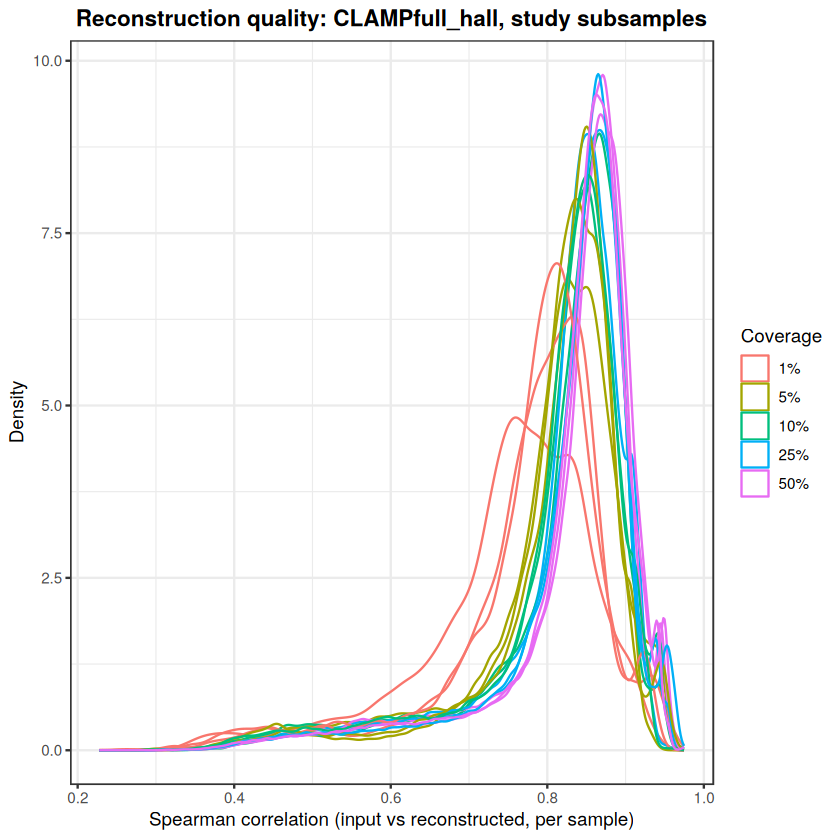

In [4]:
# Expand per-sample correlation vectors for density plots
cor_long <- dplyr::bind_rows(
  lapply(results_list, function(x) {
    data.frame(
      coverage_pct = x$coverage_pct,
      run          = x$run,
      cor          = x$cor_vector[[1]],
      stringsAsFactors = FALSE
    )
  })
)

coverage_order <- sort(unique(cor_long$coverage_pct))
cor_long$coverage_label <- factor(
  paste0(cor_long$coverage_pct, "%"),
  levels = paste0(coverage_order, "%")
)

# Plot 1: density of per-sample Spearman correlations, coloured by coverage %
p_density <- ggplot2::ggplot(
    cor_long,
    ggplot2::aes(x = cor, colour = coverage_label,
                 group = interaction(coverage_label, run))) +
  ggplot2::geom_density(alpha = 0.4) +
  ggplot2::theme_bw() +
  ggplot2::labs(
    x      = "Spearman correlation (input vs reconstructed, per sample)",
    y      = "Density",
    colour = "Coverage",
    title  = "Reconstruction quality: CLAMPfull_hall, study subsamples"
  ) +
  ggplot2::theme(plot.title = ggplot2::element_text(hjust = 0.5, face = "bold"))

p_density

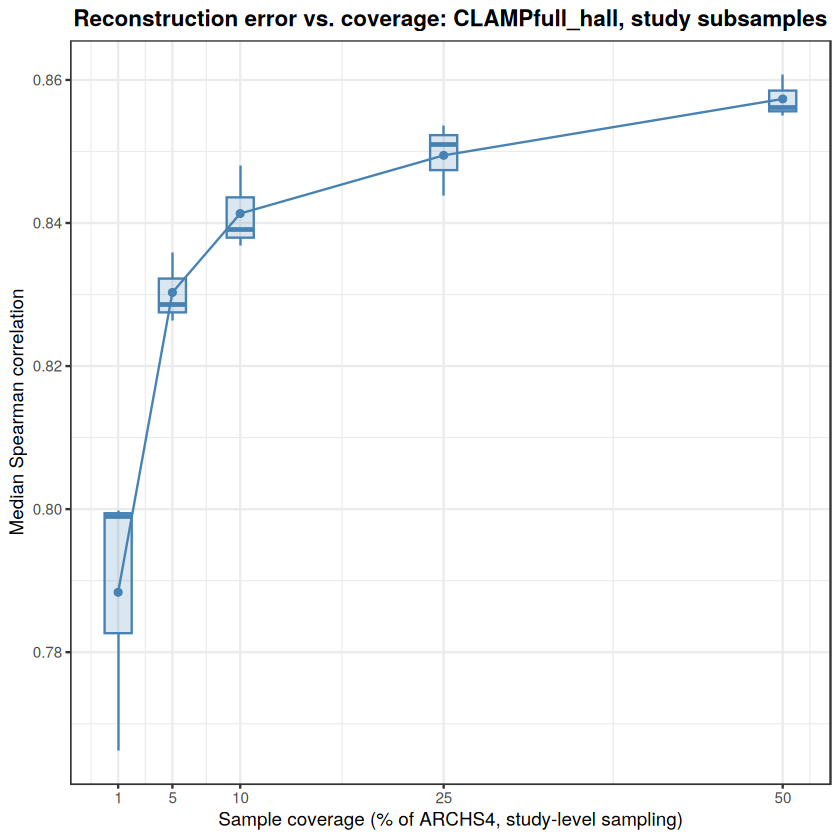

In [5]:
# Plot 2: median correlation vs coverage %, boxplot across seeds
summary_stats <- results_df %>%
  dplyr::group_by(coverage_pct) %>%
  dplyr::summarise(
    mean_median_cor = mean(median_cor),
    n_runs          = dplyr::n(),
    .groups = "drop"
  )

box_width <- min(diff(sort(unique(results_df$coverage_pct)))) * 0.5

p_line <- ggplot2::ggplot(
    results_df,
    ggplot2::aes(x = coverage_pct, y = median_cor)) +
  ggplot2::geom_boxplot(
    ggplot2::aes(group = coverage_pct),
    alpha = 0.2, fill = "steelblue", colour = "steelblue",
    outlier.shape = NA, width = box_width, position = "identity"
  ) +
  ggplot2::geom_line(
    data = summary_stats,
    ggplot2::aes(x = coverage_pct, y = mean_median_cor),
    colour = "steelblue"
  ) +
  ggplot2::geom_point(
    data = summary_stats,
    ggplot2::aes(x = coverage_pct, y = mean_median_cor),
    colour = "steelblue"
  ) +
  ggplot2::scale_x_continuous(breaks = sort(unique(results_df$coverage_pct))) +
  ggplot2::theme_bw() +
  ggplot2::labs(
    x     = "Sample coverage (% of ARCHS4, study-level sampling)",
    y     = "Median Spearman correlation",
    title = "Reconstruction error vs. coverage: CLAMPfull_hall, study subsamples"
  ) +
  ggplot2::theme(plot.title = ggplot2::element_text(hjust = 0.5, face = "bold"))

p_line